# Proyecto Transversal: Pipeline Predictivo y Flujo ETL para Datos Clínicos de Diabetes
**Programa:** Magíster en Ciencia de Datos  
**Asignatura:** Aprendizaje Basado en Problemas (ABP) - Fase 1: Definición  
**Entorno de Ejecución:** Científico / Reproducible (`requirements.txt`)  

## 1. Planteamiento de la Problemática: Calidad de Datos en la Prevalencia del Síndrome Diabético

La Diabetes Mellitus Tipo 2 (DMT2) representa uno de los desafíos de salud pública más críticos a nivel global debido a su progresión silenciosa y su alto costo asociado a complicaciones multisistémicas. La capacidad de construir modelos predictivos estables basados en el aprendizaje automático (*Machine Learning*) se ve severamente limitada en entornos de producción reales debido a la naturaleza degradada de la ingesta de datos crudos (*Raw Data*) proveniente de sistemas de registros médicos electrónicos heterogéneos.

    El conjunto de datos analizado en esta investigación (`diabetes.csv`) presenta un escenario real de ingesta hospitalaria descentralizada con una volumetría de 2045 observaciones y 9 variables clínicas. El problema técnico radica en que el dataset padece de anomalías estructurales severas que impiden su explotación analítica directa:
    
1. **Degeneración de Esquemas de Tipos:** Atributos fisiológicos críticos como la presión arterial (`BloodPressure`) se encuentran tipificados como variables cualitativas estructuradas (`object`), derivado de la presencia de cadenas de texto parásitas (`" mmHg"`) y caracteres de escape (`"?"`).

2. **Vacíos de Información Clínicos:** Variables metabólicas fundamentales, como el grosor del pliegue cutáneo (`SkinThickness`) y la concentración de insulina sérica (`Insulin`), presentan tasas significativas de datos perdidos (164 y 245 registros nulos respectivamente).

3. **Contaminación Estocástica:** Presencia de registros duplicados redundantes generados por reingresos no indexados y valores atípicos imposibles (150 años de edad o glucosas de 999 mg/dl) que distorsionan el sesgo central del modelo.

Por lo tanto, este proyecto aborda la ingeniería y el diseño metodológico de un pipeline ETL (Extract, Transform, Load) reproducible, asegurando la consistencia matemática de la matriz de entrada antes de proceder al entrenamiento de modelos de clasificación bayesianos o lineales.

## 2. Marco de Objetivos del Proyecto

### Objetivo General
Diseñar e implementar un entorno científico reproducible y un pipeline modular de extracción y diagnóstico analítico para un conjunto de datos clínico-demográfico latente de diabetes ($2045 \times 9$), caracterizando las anomalías estructurales de formato y nulidad para sentar las bases de gobernanza de datos de las fases sumativas de modelamiento predictivo.

### Objetivos Específicos
1. **Configuración de la Infraestructura Reproducible:** Configurar el aislamiento del entorno virtual (`venv`) mediante la verificación e invariabilidad de las versiones del ecosistema científico de Python (`pandas`, `numpy`, `scikit-learn`).
   
3. **Ingesta Tolerante a Fallos y Verificación de Esquema:** Desarrollar módulos orientados a objetos en Python para automatizar la extracción de datos crudos, auditando dinámicamente las dimensiones de la matriz y el mapeo de variables.

4. **Diagnóstico Estadístico de la Degradación:** Cuantificar el vector de nulidades por variable y documentar la distribución empírica de la variable objetivo (`Outcome`) para prever desbalances de clase.

## 3. Implementación de Herramientas Científicas y Diagnóstico Automatizado

Para cumplir con las exigencias de modularidad y calidad del ecosistema científico, la ingesta de datos y la auditoría estructural se encapsulan en una clase controladora de Python (`ClinicalDataPipeline`). Esta arquitectura asegura el manejo seguro de excepciones de entrada/salida (I/O) y garantiza que el flujo de ejecución sea idéntico en cualquier nodo de cómputo local o nube bajo el principio de **Restart & Run All**.

In [1]:
#Importación de librerias necesarias para realizar el análisis
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

      AUDITORÍA DE ENTORNO VIRTUAL CIENTÍFICO             
  ✓ Python_Version  : 3.12.13
  ✓ Pandas_Version  : 3.0.3
  ✓ NumPy_Version   : 2.4.6
  ✓ Matplotlib_Ver  : 3.10.9
  ✓ Seaborn_Version : 0.13.2
  ✓ Scikit-Learn    : 1.8.0
----------------------------------------------------------
[ÉXITO] Matriz de datos extraída correctamente desde '../data/raw/diabetes_raw.csv'.

          DIAGNÓSTICO ESTRUCTURAL Y METADATOS             
• Dimensión Observaciones (Filas):   2045
• Dimensión de Campos (Columnas):    9
----------------------------------------------------------
Índice   | Variable Clínica             | Dtype Nativo
----------------------------------------------------------
  [01]   | Pregnancies                  | int64
  [02]   | Glucose                      | int64
  [03]   | BloodPressure                | str
  [04]   | SkinThickness                | float64
  [05]   | Insulin                      | float64
  [06]   | BMI                          | float64
  [07]   | Diabetes

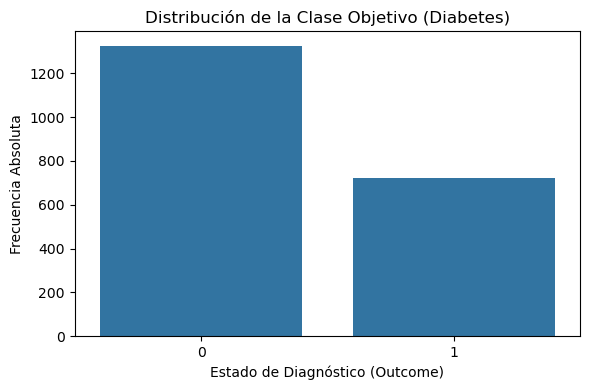

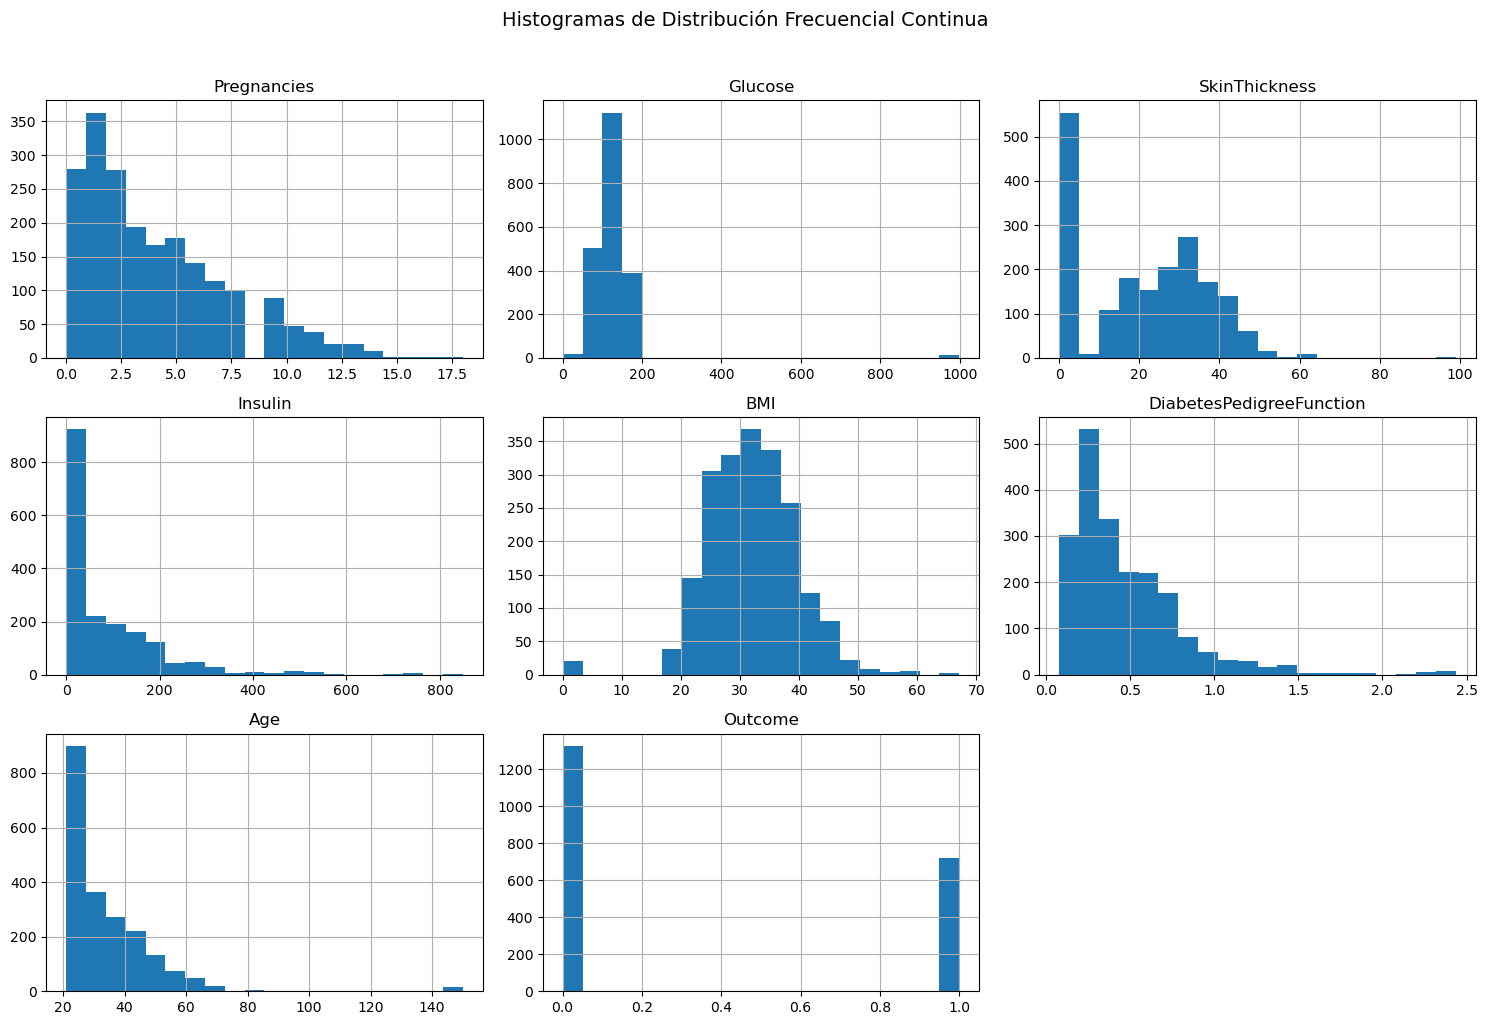

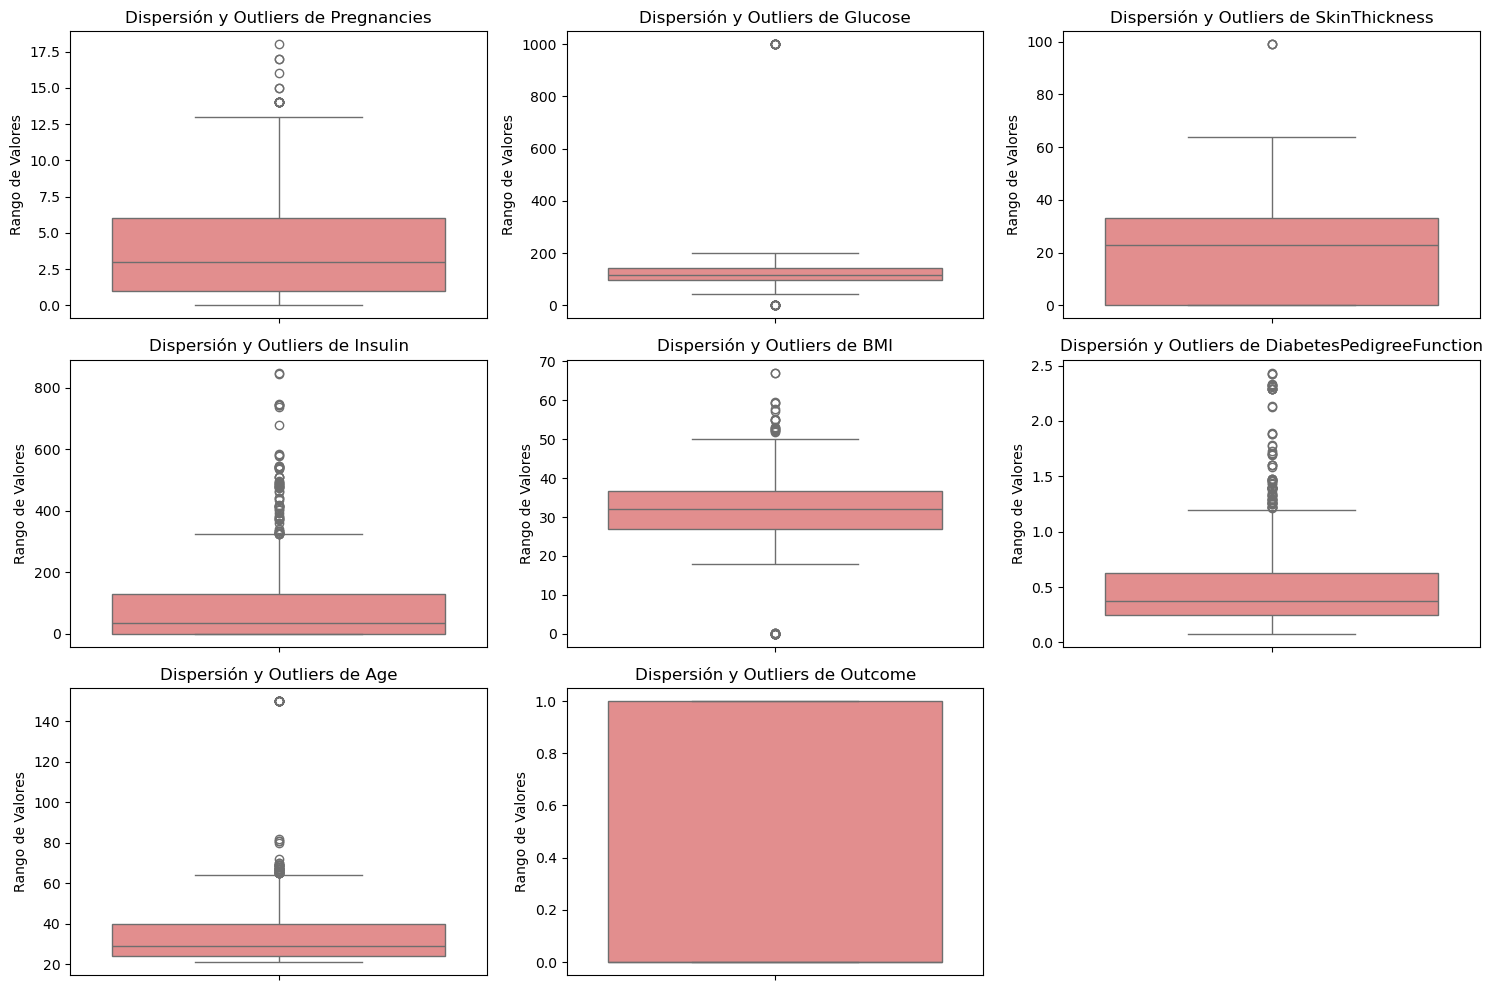

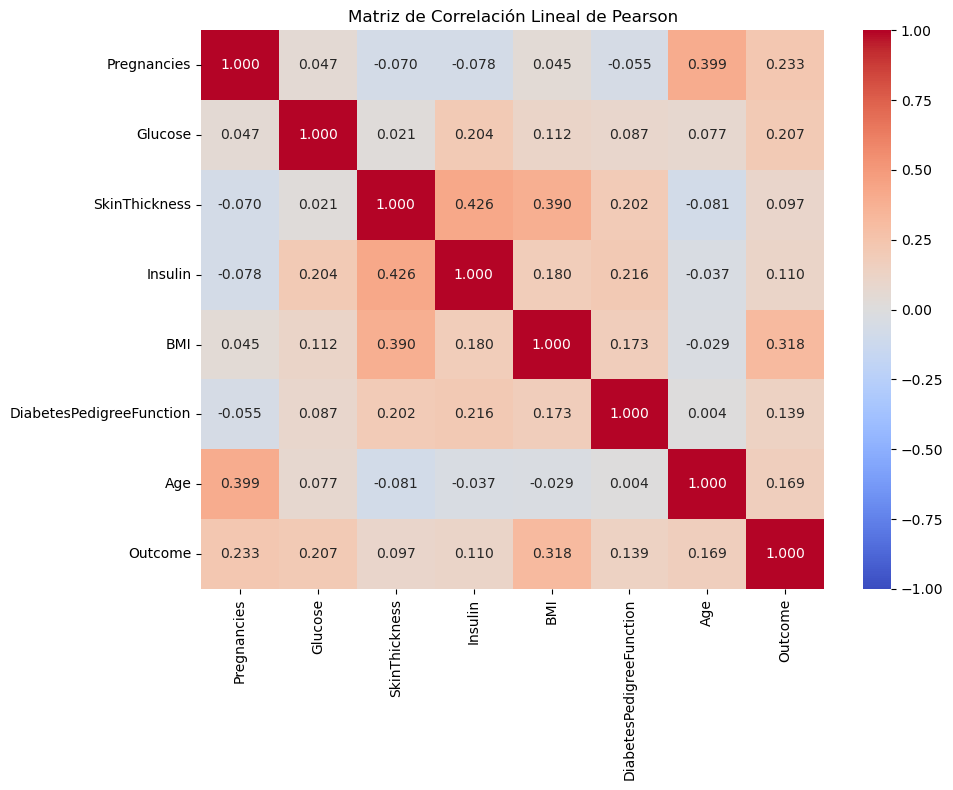


Variables ordenadas por fuerza de asociación con el Outcome:
Outcome                     1.000000
BMI                         0.317969
Pregnancies                 0.233272
Glucose                     0.206856
Age                         0.169171
DiabetesPedigreeFunction    0.138515
Insulin                     0.110285
SkinThickness               0.097234
Name: Outcome, dtype: float64


In [2]:
class ClinicalDataPipeline:
    """
    Controlador de Ingeniería de Datos encargado de gestionar el aislamiento,
    la ingesta segura, la auditoría estructural y el perfilado estático 
    del dataset clínico de diabetes para entornos de producción.
    """
    def __init__(self, data_path: str):
        """
        Inicializa la tubería de datos fijando la ruta del activo informático.
        """
        self.data_path = data_path
        self.dataframe = None
        self.traducciones = {
            'Pregnancies': 'Embarazos',
            'Glucose': 'Glucosa',
            'BloodPressure': 'Presión Arterial',
            'SkinThickness': 'Espesor de Piel',
            'Insulin': 'Insulina',
            'BMI': 'Índice de Masa Corporal',
            'DiabetesPedigreeFunction': 'Función Hereditaria de Diabetes',
            'Age': 'Edad',
            'Outcome': 'Resultado'
        }
        
    def verificar_entorno_reproducible(self) -> dict:
        """
        Audita las versiones de las librerías científicas activas en el Kernel
        para garantizar la trazabilidad e invariabilidad del entorno virtual.
        """
        import sklearn
        import matplotlib
        
        reporte_sistema = {
            "Python_Version": sys.version.split()[0],
            "Pandas_Version": pd.__version__,
            "NumPy_Version": np.__version__,
            "Matplotlib_Ver": matplotlib.__version__,
            "Seaborn_Version": sns.__version__,
            "Scikit-Learn": sklearn.__version__
        }
        print("==========================================================")
        print("      AUDITORÍA DE ENTORNO VIRTUAL CIENTÍFICO             ")
        print("==========================================================")
        for libreria, version in reporte_sistema.items():
            print(f"  ✓ {libreria:<15} : {version}")
        print("----------------------------------------------------------")
        return reporte_sistema

    def ejecutar_ingesta(self) -> bool:
        """
        Realiza la extracción segura del dataset en disco manejando excepciones 
        de Entrada/Salida (I/O) para evitar fallos catastróficos en el Kernel.
        """
        if not os.path.exists(self.data_path):
            print(f"[CRÍTICO] Fallo de Ingesta: Archivo '{self.data_path}' no localizado.")
            return False
        try:
            self.dataframe = pd.read_csv(self.data_path, sep=';')
            print(f"[ÉXITO] Matriz de datos extraída correctamente desde '{self.data_path}'.")
            return True
        except Exception as e:
            print(f"[CRÍTICO] Error inesperado en el parser del archivo CSV: {e}")
            return False

    def auditar_esquema_volumetrico(self):
        """
        Inspecciona las dimensiones del tensor y mapea los tipos de datos nativos
        (dtypes) para documentar anomalías estructurales de tipado.
        """
        if self.dataframe is None:
            print("[ALERTA] Ingesta previa requerida para auditar el esquema.")
            return
        
        filas, columnas = self.dataframe.shape
        print("\n==========================================================")
        print("          DIAGNÓSTICO ESTRUCTURAL Y METADATOS             ")
        print("==========================================================")
        print(f"• Dimensión Observaciones (Filas):   {filas}")
        print(f"• Dimensión de Campos (Columnas):    {columnas}")
        print("----------------------------------------------------------")
        print(f"{'Índice':<8} | {'Variable Clínica':<28} | {'Dtype Nativo'}")
        print("----------------------------------------------------------")
        
        for idx, col in enumerate(self.dataframe.columns, 1):
            print(f"  [{idx:02d}]   | {col:<28} | {self.dataframe[col].dtype}")
        print("==========================================================")

    def cuantificar_degradacion_datos(self):
        """
        Calcula el vector de pérdidas absolutas y relativas por variable, 
        así como la tasa de redundancia estructural (duplicados exactos).
        """
        if self.dataframe is None:
            return
        
        print("\n==========================================================")
        print("        VECTOR DE DEGRADACIÓN: NULIDADES Y DUPLICADOS     ")
        print("==========================================================")
        
        vector_nulos = self.dataframe.isnull().sum()
        for variable, nulos in vector_nulos.items():
            porcentaje = (nulos / len(self.dataframe)) * 100
            nombre_espanol = self.traducciones.get(variable, "No traducida")
            print(f"  • {variable:<28} ({nombre_espanol}): {nulos:<4} nulos ({porcentaje:.2f}%)")
            
        duplicados_exactos = self.dataframe.duplicated().sum()
        print("----------------------------------------------------------")
        print(f"• Total de registros redundantes (Duplicados): {duplicados_exactos}")
        print("==========================================================")

    def analizar_balance_target(self):
        """
        Audita la distribución empírica de la variable categórica dependiente
        para alertar sobre desbalances en el espacio de entrenamiento.
        """
        if self.dataframe is None:
            return
            
        print("\n==========================================================")
        print("           DISTRIBUCIÓN EMPÍRICA DE LA CLASE TARGET       ")
        print("==========================================================")
        conteos = self.dataframe['Outcome'].value_counts()
        proporciones = self.dataframe['Outcome'].value_counts(normalize=True) * 100
        
        print(f"  [Clase 0 - Sano]:      {conteos[0]:<5} registros ({proporciones[0]:.2f}%)")
        print(f"  [Clase 1 - Diabético]: {conteos[1]:<5} registros ({proporciones[1]:.2f}%)")
        print("==========================================================")

    def generar_perfilado_grafico(self):
        """
        Orquesta el motor gráfico para renderizar las distribuciones visuales,
        diagramas de dispersión de outliers y la matriz de correlación lineal.
        """
        if self.dataframe is None:
            return
            
        print("\n[PROCESAMIENTO] Renderizando paneles gráficos para el informe...")
        
        # 1. Gráfico de Barras - Distribución de la Variable Objetivo
        plt.figure(figsize=(6, 4))
        sns.countplot(data=self.dataframe, x='Outcome')
        plt.title("Distribución de la Clase Objetivo (Diabetes)")
        plt.xlabel("Estado de Diagnóstico (Outcome)")
        plt.ylabel("Frecuencia Absoluta")
        plt.tight_layout()
        plt.show()

        # 2. Histogramas de Distribución Empírica
        self.dataframe.hist(figsize=(15, 10), bins=20)
        plt.suptitle("Histogramas de Distribución Frecuencial Continua", y=1.02, fontsize=14)
        plt.tight_layout()
        plt.show()

        # 3. Diagramas de Caja (Boxplots) para Detección de Outliers Clínicos
        columnas_numericas = self.dataframe.select_dtypes(include=['int64', 'float64']).columns
        plt.figure(figsize=(15, 10))
        for i, col in enumerate(columnas_numericas):
            plt.subplot(3, 3, i + 1)
            sns.boxplot(y=self.dataframe[col], color="lightcoral")
            plt.title(f"Dispersión y Outliers de {col}")
            plt.ylabel("Rango de Valores")
        plt.tight_layout()
        plt.show()

        # 4. Mapa de Calor (Heatmap) de la Matriz de Correlación de Pearson
        plt.figure(figsize=(10, 8))
        matriz_corr = self.dataframe.corr(numeric_only=True)
        sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
        plt.title("Matriz de Correlación Lineal de Pearson")
        plt.tight_layout()
        plt.show()
        
        # 5. Vector ordenado de asociación con el Target
        print("\nVariables ordenadas por fuerza de asociación con el Outcome:")
        print(matriz_corr['Outcome'].sort_values(ascending=False))


# ==========================================================
# INVOCACIÓN ORQUESTADA PARA CONTROL DE TRAZABILIDAD
# ==========================================================
if __name__ == "__main__":
    # 1. Configuración de la ruta indexada al nuevo árbol de directorios oficial
    RUTA_DATASET = "../data/raw/diabetes_raw.csv"

    # 2. Instanciación y ejecución secuencial del pipeline de Fase 1
    pipeline = ClinicalDataPipeline(data_path=RUTA_DATASET)
    
    pipeline.verificar_entorno_reproducible()
    
    if pipeline.ejecutar_ingesta():
        pipeline.auditar_esquema_volumetrico()
        pipeline.cuantificar_degradacion_datos()
        pipeline.analizar_balance_target()
        pipeline.generar_perfilado_grafico()